In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import sys
path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(splitted[0]+os.sep, splitted[1], splitted[2], splitted[3])
src_path = os.path.join(user_independent, 'GitHub', 'Photoswitching')
sys.path.append(src_path)

import src.miscellaneous as mi
import src.figure as fi
import src.blinking as bl
import experimental_data_analysis as eda

%load_ext autoreload
%autoreload 2

In [3]:
exp_data = eda.ExperimentalData(file=r"C:\Users\ebert\Desktop\Fluorocubes_AF647_widefield_dSTORM\Fluorocubes_1x(0)_kontrolle\1x(0)xAF647_5ms_120kfr_Epi_EMCCD_crop_f7,5_400mw_256x256px_quad_line-PFS_1.txt")
exp_data.data

,x_position,x_uncertain,y_position,y_uncertain,frame,intensity,fit,background
0,19347.50,25,22437.000,25,0,11736.20,1021590.0,625.343
1,6807.95,25,22979.400,25,0,9243.22,869105.0,631.770
2,24813.80,25,21359.400,25,0,10450.10,1159410.0,639.918
3,16650.40,25,278.715,25,0,8321.14,860542.0,624.265
4,10181.00,25,25229.600,25,0,5022.90,533402.0,592.715
...,...,...,...,...,...,...,...,...
40543,27465.70,25,25982.900,25,119926,2968.89,620746.0,596.517
40544,27715.30,25,25933.000,25,119927,1533.61,488657.0,590.035
40545,11352.90,25,25690.200,25,119937,2174.08,460481.0,583.781
40546,11400.10,25,25733.800,25,119938,4764.45,674141.0,585.126


In [4]:
exp_data.cluster(eps=25, min_samples=3)

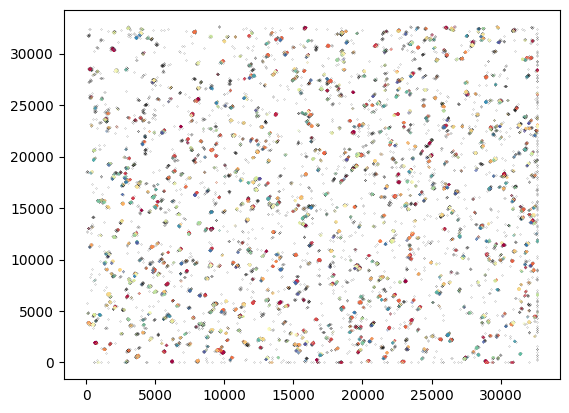

In [5]:
exp_data.plot()

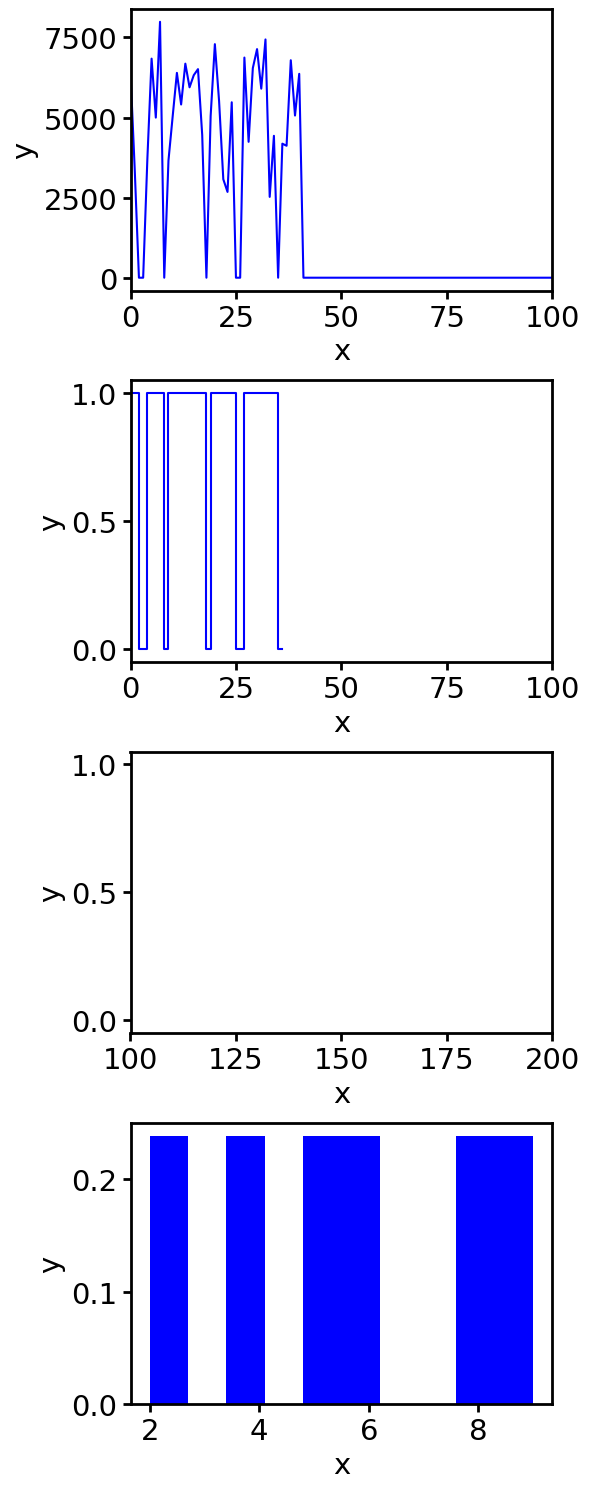

In [10]:
event_time_series = exp_data.get_event_series(5)
on_periods, off_periods, on_frames, off_frames = bl.get_blinking_statistics(event_time_series)
on_off_frames, on_off_values = bl.get_analytical_off_statistics(off_frames, off_periods)

# plot it
axes = fi.universal_figure(nrows=4, fig_height=15)
fi.universal_figure(axes=axes[0], type_='line', data=[event_time_series.index, event_time_series.values], xlim=[0, 100])
fi.universal_figure(axes=axes[1], type_='line', data=[on_off_frames, on_off_values], xlim=[0, 100])
fi.universal_figure(axes=axes[2], type_='line', data=[on_off_frames, on_off_values], xlim=[100, 200])
fi.universal_figure(axes=axes[3], type_='hist', data=on_periods, density=True)
fig = mi.get_figure(axes)
fig.tight_layout()

[ 4  3  5  2  4  1  1  1  8  2  2  1  2  1  2  1  1  2  2  1  2  4  1  3
  2  2  1  1  1  7  1  2 11  1  3  1  1  2  1  1  1  1  1  2  1  2  2  2] [    1     1     1     1 29866     3     1     2     7     5     1     3
     1     3     2     1     1     1     1     1     1     2     1     1
     1     2     1 16115     3     7     1     3     1     3     2     3
 20785     2     1     2 24049     1     3     5     1     1     5] [ 2051  2056  2060  2066  2069 31939 31943 31945 31948 31963 31970 31973
 31977 31980 31984 31988 31990 31992 31995 31998 32000 32003 32009 32011
 32015 32018 32022 32024 48140 48144 48158 48160 48165 48177 48181 48186
 48190 68976 68980 68982 68985 93035 93037 93041 93048 93050 93053 93060] [ 2055  2059  2065  2068  2073 31940 31944 31946 31956 31965 31972 31974
 31979 31981 31986 31989 31991 31994 31997 31999 32002 32007 32010 32014
 32017 32020 32023 32025 48141 48151 48159 48162 48176 48178 48184 48187
 48191 68978 68981 68983 68986 93036 93038 93043 93049

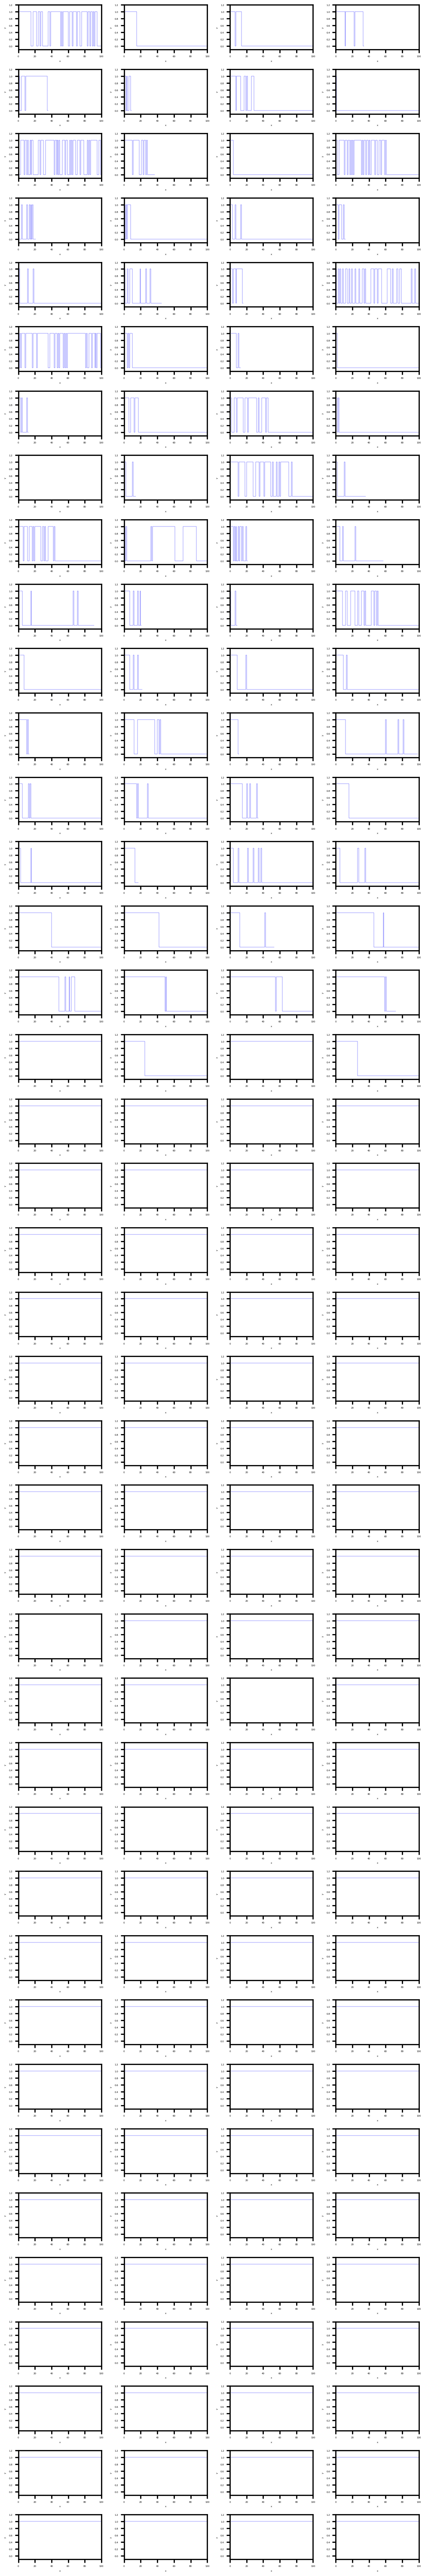

In [5]:
nrows = 40
ncols = 4


axes = fi.universal_figure(nrows=nrows, ncols=ncols, fig_height=nrows*1.5, fig_width=10)
j = 0
h = 0
for i in np.arange(0, nrows*ncols, 1):
    if j > ncols-1:
        h += 1
        j = 0
    event_time_series = exp_data.get_event_series(i)
    on_periods, off_periods, on_frames, off_frames = bl.get_blinking_statistics(event_time_series)
    on_off_frames, on_off_values = bl.get_analytical_off_statistics(off_frames, off_periods)
    # fi.universal_figure(axes=axes[h, j], type_='line', data=[event_time_series.index, event_time_series.values], 
    #                     xlim=[0, 100], fontsize=4, lw=0.3)
    if h > 35:
        print(on_periods, off_periods, on_frames, off_frames)
    fi.universal_figure(axes=axes[h, j], type_='line', data=[on_off_frames, on_off_values], xlim=[0, 100],
                        fontsize=4, lw=0.3, ylim=[-0.1, 1.2])
    j += 1
fig = mi.get_figure(axes)
fig.tight_layout()